In [1]:
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
import pandas as pd
from joblib import Parallel, delayed
import numpy as np
import anndata as ad
import h5py
import scvelo as scv
import warnings

In [2]:
gray_green = LinearSegmentedColormap.from_list(
    "gray_green", ["#D3D3D3", "#02500e", "#001203"]
)
gray_orange = LinearSegmentedColormap.from_list(
    "gray_orange", ["#D3D3D3", "#f76d48", "#FA4616"]
)

In [3]:
adata_transformed = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/data/processed/m3454_adata_subset_again_(50,34)_(0.1,1.2)_8_3_25.h5ad")

In [4]:
# set once in the main process
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*na_action.*Categorical\.map.*",
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r"No data for colormapping provided via 'c'.*cmap.*",)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)

In [5]:
keep = [0,1,2,3,5,6]
adata_subset = adata_transformed[adata_transformed.obs["leiden"].isin(map(str, keep))].copy()

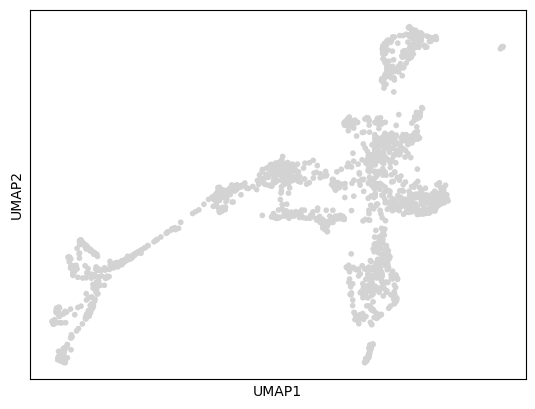

In [6]:
sc.pl.umap(adata_transformed)

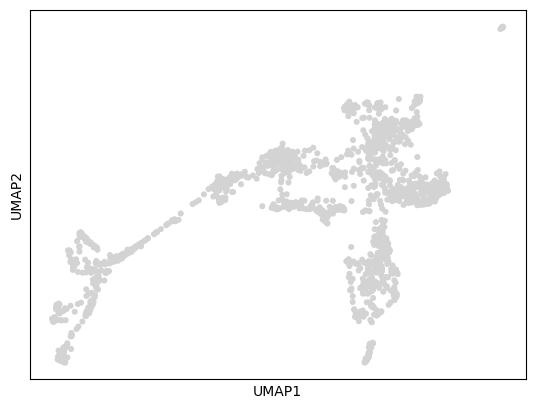

In [7]:
sc.pl.umap(adata_subset)

In [6]:
adata_subset

AnnData object with n_obs × n_vars = 1578 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [7]:
#save point
adata_subset_test=adata_subset.copy()

In [ ]:
# --- USER PARAMETERS ---
n_pcs_list = [10, 12, 15, 18, 21, 24, 27, 30, 32, 34, 36, 38, 40, 45, 50]
n_neighbors_list = [10, 12, 15, 18, 21, 24, 27, 30, 32, 34, 36, 38, 40, 45, 50]
n_jobs = 4                # Adjust based on memory (10 x ~4GB = ~40GB usage)
batch_size = n_jobs        # Jobs per batch = number of parallel workers
seed=13

resolution = 0.3
point_size = 20
max_pcs = max(n_pcs_list)

# --- INPUT DATA ---
adata_subset_test = adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50, svd_solver='arpack',random_state=seed)

adata_temp = adata_subset_test.copy()


# --- GRID ---
param_grid = [(pcs, nn) for pcs in n_pcs_list for nn in n_neighbors_list]
n_total = len(param_grid)
n_batches = int(np.ceil(n_total / batch_size))

# --- UMAP Function ---
def compute_umap_npc_nn(n_pcs, n_neighbors):
    adata_temp = adata_subset_test.copy()
    sc.pp.neighbors(adata_temp, n_neighbors=n_neighbors, n_pcs=n_pcs,random_state=seed)
    sc.tl.umap(adata_temp,random_state=seed)
    sc.tl.leiden(adata_temp, resolution=resolution,random_state=seed)
    return adata_temp, n_pcs, n_neighbors

# --- RUN BATCHES ---
for batch_i in range(n_batches):
    start = batch_i * batch_size
    end = min((batch_i + 1) * batch_size, n_total)
    batch = param_grid[start:end]

    print(f"\n▶ Batch {batch_i+1}/{n_batches} | Combos {start+1}–{end}")
    #print(adata_temp.obs["leiden"].value_counts(dropna=False))

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_umap_npc_nn)(pcs, nn) for pcs, nn in batch
    )

    # Grid dimensions
    unique_pcs = sorted(set(pcs for pcs, _ in batch))
    unique_nn = sorted(set(nn for _, nn in batch))
    n_rows = len(unique_pcs)
    n_cols = len(unique_nn)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5), sharex=True, sharey=True)

    # If only one row or col, axes is not 2D
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    for i, (adata_temp, n_pcs, n_neighbors) in enumerate(results):
        row = unique_pcs.index(n_pcs)
        col = unique_nn.index(n_neighbors)
        ax = axes[row, col]

        sc.pl.umap(
            adata_temp,
            color="leiden",
            title=f"pcs={n_pcs}, nn={n_neighbors}",
            ax=ax,
            show=False,
            legend_loc="on data",
            size=point_size,
            cmap="viridis"
        )
        ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

In [ ]:
#testing out different spreads
min_dist_list = [0.1,0.3,0.5,0.7,0.8,0.9]
spread_list = [0.8,1.0, 1.3, 1.6, 1.9, 2.2]
adata_subset_test=adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50)
n_rows = len(min_dist_list)
n_cols = len(spread_list)

fig_width = n_cols * 6
fig_height = n_rows * 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)

point_size = max(10, 60 - 5 * max(n_rows, n_cols))

for row, min_dist in enumerate(min_dist_list):
    for col, spread in enumerate(spread_list):
        ax = axes[row, col]
        adata_temp = adata_subset_test.copy()
        

        sc.tl.pca(adata_temp, n_comps=50)        
        sc.pp.neighbors(adata_temp, n_neighbors=32, n_pcs=40)
        sc.tl.umap(adata_temp, min_dist=min_dist, spread=spread)
        sc.tl.leiden(adata_temp)
        
        sc.pl.umap(
            adata_temp,
            color="leiden",
            title=f"min_dist={min_dist}, spread={spread}",
            cmap="viridis",
            ax=ax,
            show=False,
            size=point_size,
            legend_loc="on top"
        )

for ax in axes.flat:
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(values):


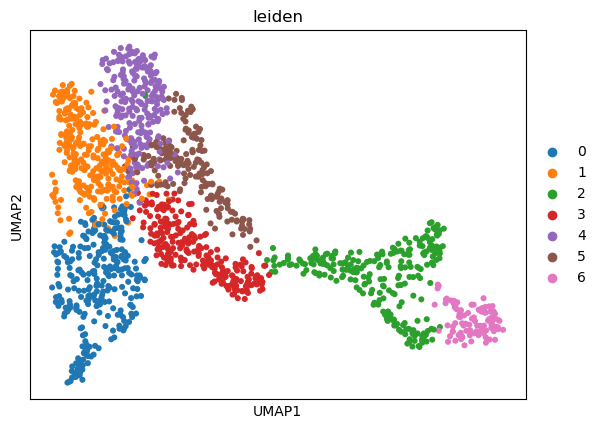

In [39]:
#final subset UMAP
seed=13
n_pcs=12
n_neighbors=34
min_dist=.32
spread=.25
adata_subset_test=adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50, svd_solver='arpack',random_state=seed)
sc.pp.neighbors(adata_subset_test, n_pcs=n_pcs, n_neighbors=n_neighbors,random_state=seed)  
sc.tl.umap(adata_subset_test,random_state=seed,min_dist=min_dist,spread=spread)
sc.tl.leiden(adata_subset_test, resolution=0.3,random_state=seed)
sc.pl.umap(adata_subset_test, color="leiden", cmap="viridis",#legend_loc="on data",
         #save=f"_subset_combined_umap.pdf 
          )

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(values):


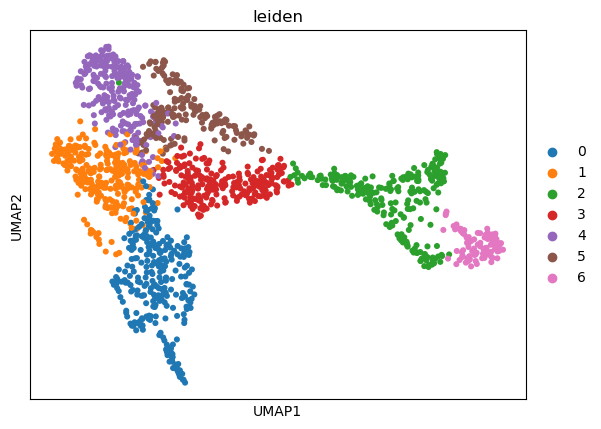

Filtered out 958 genes that are detected 20 counts (spliced).
Normalized count data: X, spliced, unspliced.
computing neighbors


/scratch/local/9436980/ipykernel_3249547/338585704.py:29: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata_velocity, n_pcs=n_pcs, n_neighbors=n_neighbors)
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute PCA with Scanpy first.
  _set_pca(adata=adata, n_pcs=n_pcs, use_highly_variable=use_highly_variable)


    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 8/128 cores)
    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/squa

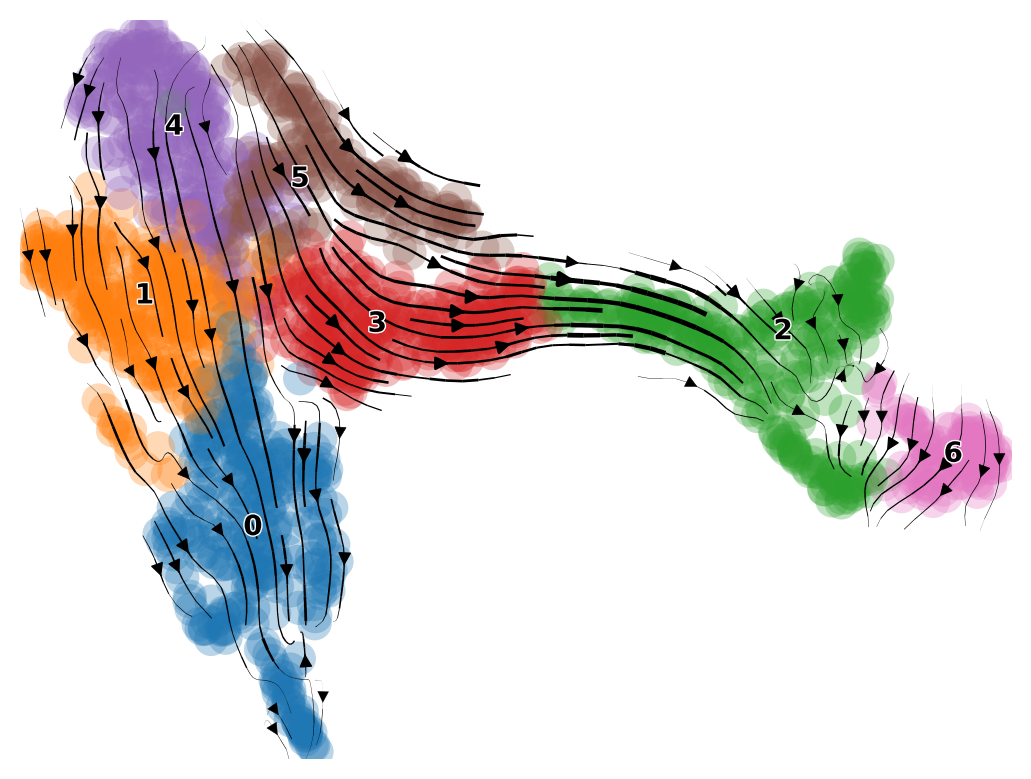

In [28]:
#final subset UMAP
seed=13
n_pcs=12
n_neighbors=34
min_dist=.23
spread=.27
adata_subset_test=adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50, svd_solver='arpack',random_state=seed)
sc.pp.neighbors(adata_subset_test, n_pcs=n_pcs, n_neighbors=n_neighbors,random_state=seed)  
sc.tl.umap(adata_subset_test,random_state=seed,min_dist=min_dist,spread=spread)
sc.tl.leiden(adata_subset_test, resolution=0.3,random_state=seed)
sc.pl.umap(adata_subset_test, color="leiden", cmap="viridis",#legend_loc="on data",
         #save=f"_subset_combined_umap.pdf 
          )
adata = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/data/raw/m5_adata_egfp.h5ad")
adata_raw = adata.copy() 
adata_raw = adata_raw[adata_subset_test.obs_names, :].copy()
adata_raw = adata_raw[:, adata_subset_test.var_names].copy()
adata_raw.obsm["X_umap"] = adata_subset_test.obsm["X_umap"]
adata_raw.obs["leiden"]  = adata_subset_test.obs["leiden"]
adata_velocity=adata_raw.copy()
scv.pp.filter_and_normalize(
    adata_velocity,
    min_counts=20,
    min_cells=5,
    n_top_genes=None, 
    log=False
)
scv.pp.moments(adata_velocity, n_pcs=n_pcs, n_neighbors=n_neighbors)
#scv.tl.recover_dynamics(adata_velocity, n_jobs=8)
scv.tl.velocity(adata_velocity, mode="stochastic", n_jobs=8)
scv.tl.velocity_graph(adata_velocity, n_jobs=8)
scv.pl.velocity_embedding_stream(adata_velocity, basis='umap',dpi=200,color="leiden", title="",
                                 #save=f"plus345_2_subset_velocity_stream_grey.svg"
                                )

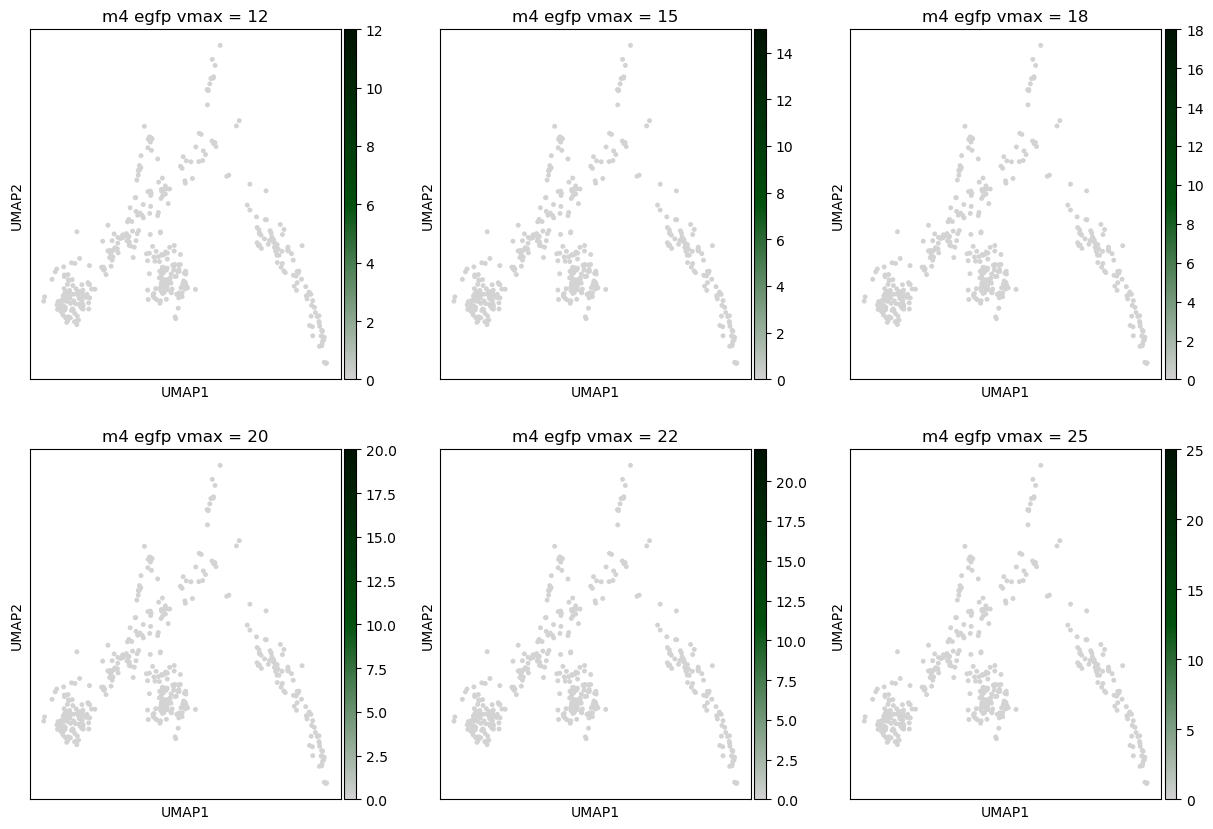

In [35]:
#testing different vmax on same sample
sample='m4'
adata_sample = adata_subset_test[adata_subset_test.obs["sample"] == f"{sample}"].copy()

vmax_values = [12,15,18,20,22,25]
#vmax_values = [2,5,8,10,12,6]

ncols = 3
nrows = (len(vmax_values) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 5 * nrows))

axes = axes.flatten()

for i, vmax in enumerate(vmax_values):
    ax = axes[i]
    sc.pl.umap(
        adata_sample,
        color="egfp",
        vmin=0,
        vmax=vmax,
        size=50,
        title=f"{sample} egfp vmax = {vmax}",
        cmap=gray_green,
        show=False,
        ax=ax  
    )

In [ ]:
sample='m4'
gene='egfp'
adata_sample = adata_subset_test[adata_subset_test.obs["sample"] == f"{sample}"].copy()
sc.pl.umap(
    adata_sample,
    color=gene,
    vmin=0,
    vmax=18,
    size=50,
    title=f'{sample}_{gene}',
    cmap=gray_softorange_orangered,
    #save=f"_subset_umap_{sample}_{gene}.pdf"
)